# CP2 — APIs, energias renováveis e aprendizado de máquina

Duas tarefas independentes, com **três algoritmos em cada uma**:

| Tarefa | Fonte dos dados | Tipo | Algoritmos comparados |
|---|---|---|---|
| 1 — Fonte de geração (Solar, Eólica, Hidráulica) | ANEEL / SIGA | Classificação | Regressão Logística, KNN, Random Forest |
| 2 — Radiação solar em Petrolina (PE) | Open-Meteo (01/04/2025 a 30/06/2025) | Regressão | Regressão Linear, Árvore de Decisão, Random Forest |

**Como executar:** rode as células na ordem. Se os dois CSVs já estiverem na pasta do notebook, eles são lidos direto; se não estiverem, a seção 0 os gera consultando as APIs públicas (não há token).

## 0. Imports e geração dos CSVs (APIs públicas, sem token)

In [1]:
import os, json, csv, urllib.parse, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Classificação
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)

# Regressão
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=100) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

def gerar_csv_aneel(caminho="aneel_classificacao_orange.csv"):
    url = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
    id_recurso = "11ec447d-698d-4ab8-977f-b424d5deee6a"
    fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica", "PCH": "Hidráulica", "CGH": "Hidráulica"}
    linhas = []
    for sigla in fontes:
        resp = consultar_api(url, {"resource_id": id_recurso,
                                   "filters": json.dumps({"SigTipoGeracao": sigla}),
                                   "limit": 1200})
        if not resp.get("success"):
            raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
        for r in resp["result"]["records"]:
            p = numero(r.get("MdaPotenciaOutorgadaKw"))
            la = numero(r.get("NumCoordNEmpreendimento"))
            lo = numero(r.get("NumCoordEEmpreendimento"))
            if all(v is not None for v in (p, la, lo)):
                linhas.append([p, la, lo, fontes[sigla]])
    with open(caminho, "w", newline="", encoding="utf-8-sig") as f:
        w = csv.writer(f); w.writerow(["potencia_kw", "latitude", "longitude", "fonte"]); w.writerows(linhas)

def gerar_csv_meteo(caminho="meteo_regressao_orange.csv"):
    nomes = ["temperature_2m", "relative_humidity_2m", "cloud_cover", "wind_speed_10m", "shortwave_radiation"]
    resp = consultar_api("https://archive-api.open-meteo.com/v1/archive",
                         {"latitude": -9.39, "longitude": -40.50,
                          "start_date": "2025-04-01", "end_date": "2025-06-30",
                          "timezone": "America/Recife", "hourly": ",".join(nomes)})
    h = resp["hourly"]; linhas = []
    for i, t in enumerate(h["time"]):
        hora = int(t[11:13]); v = [h[n][i] for n in nomes]
        if 7 <= hora <= 17 and all(x is not None for x in v):
            linhas.append([t, *v[:4], hora, v[4]])
    with open(caminho, "w", newline="", encoding="utf-8-sig") as f:
        w = csv.writer(f)
        w.writerow(["data_hora", "temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
        w.writerows(linhas)

if not os.path.exists("aneel_classificacao_orange.csv"):
    gerar_csv_aneel()
if not os.path.exists("meteo_regressao_orange.csv"):
    gerar_csv_meteo()
print("CSVs disponíveis:", os.path.exists("aneel_classificacao_orange.csv"), os.path.exists("meteo_regressao_orange.csv"))

CSVs disponíveis: True True


# Tarefa 1 — Classificação da fonte (ANEEL)

**Pergunta:** só com a potência outorgada e a localização, dá para dizer se um empreendimento é Solar, Eólico ou Hidráulico?

`X` = `potencia_kw`, `latitude`, `longitude`; `y` = `fonte`. Nome, código CEG, sigla e descrição **não** entram em `X`, porque entregariam a resposta.

### 1.1 Exploração dos dados

In [3]:
aneel = pd.read_csv("aneel_classificacao_orange.csv", encoding="utf-8-sig")
print("Linhas e colunas:", aneel.shape)
print("\nTipos:\n", aneel.dtypes)
print("\nValores ausentes:\n", aneel.isna().sum())
print("\nLinhas duplicadas:", aneel.duplicated().sum())
aneel.describe()

Linhas e colunas: (3876, 4)

Tipos:
 potencia_kw    float64
latitude       float64
longitude      float64
fonte              str
dtype: object

Valores ausentes:
 potencia_kw    0
latitude       0
longitude      0
fonte          0
dtype: int64

Linhas duplicadas: 28


,potencia_kw,latitude,longitude
count,"3,876.0000","3,876.0000","3,876.0000"
mean,"42,014.6815",-12.6940,-46.1583
std,"301,636.5878",9.5005,8.3575
min,0.1600,-33.7228,-69.9414
25%,440.0000,-21.1421,-52.5618
50%,"12,680.0000",-10.4695,-47.3937
75%,"30,000.0000",-4.1278,-41.2800
max,"11,233,100.0000",3.8314,0.0000


In [4]:
contagem = aneel["fonte"].value_counts()
print(contagem)
print((contagem / len(aneel) * 100).round(1).astype(str) + " %")

fonte
Hidráulica    1476
Solar         1200
Eólica        1200
Name: count, dtype: int64
fonte
Hidráulica    38.1 %
Solar         31.0 %
Eólica        31.0 %
Name: count, dtype: str


**Atenção ao interpretar as classes.** A API foi consultada com `limit=1200` por sigla. Por isso Solar e Eólica têm exatamente 1200 linhas e Hidráulica (soma de UHE, PCH e CGH) tem 1476. Essas quantidades vêm da consulta e **não representam a participação de cada fonte na matriz energética brasileira**. As classes ficam razoavelmente equilibradas, então Accuracy é uma métrica aceitável, mas Precision, Recall e F1 continuam sendo reportadas.

Potência (kW) por fonte:
Solar com potência <= 1 kW: 754 de 1200
Linhas com latitude ou longitude exatamente 0: 47


,count,mean,std,min,25%,50%,75%,max
fonte,,,,,,,,
Eólica,"1,200.0000","30,782.7699","13,800.5978",0.1600,"23,100.0000","29,600.0000","37,200.0000","105,000.0000"
Hidráulica,"1,476.0000","75,809.1583","486,419.5790",0.9900,990.0000,"4,000.0000","17,000.0000","11,233,100.0000"
Solar,"1,200.0000","11,679.3867","18,374.8552",0.2600,1.0000,1.0000,"28,880.0000","137,480.0000"


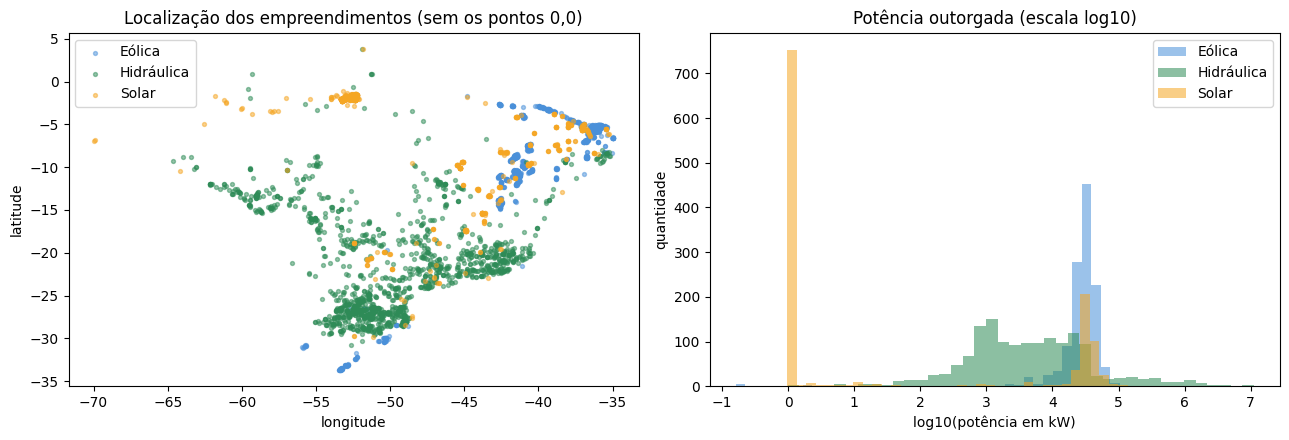

In [5]:
print("Potência (kW) por fonte:")
display(aneel.groupby("fonte")["potencia_kw"].describe())

print("Solar com potência <= 1 kW:", ((aneel.fonte == "Solar") & (aneel.potencia_kw <= 1)).sum(), "de", (aneel.fonte == "Solar").sum())
print("Linhas com latitude ou longitude exatamente 0:", ((aneel.latitude == 0) | (aneel.longitude == 0)).sum())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
cores = {"Solar": "#f5a623", "Eólica": "#4a90d9", "Hidráulica": "#2e8b57"}
for f, g in aneel.groupby("fonte"):
    g_mapa = g[(g.latitude != 0) & (g.longitude != 0)]   # pontos (0, 0) distorcem o mapa
    axes[0].scatter(g_mapa.longitude, g_mapa.latitude, s=8, alpha=.5, label=f, color=cores[f])
    axes[1].hist(np.log10(g.potencia_kw), bins=40, alpha=.55, label=f, color=cores[f])
axes[0].set(title="Localização dos empreendimentos (sem os pontos 0,0)", xlabel="longitude", ylabel="latitude"); axes[0].legend()
axes[1].set(title="Potência outorgada (escala log10)", xlabel="log10(potência em kW)", ylabel="quantidade"); axes[1].legend()
plt.tight_layout(); plt.show()

**O que se vê:**
- Cerca de 750 dos 1200 empreendimentos solares têm potência de **1 kW ou menos**, um valor que parece placeholder do cadastro. Isso já separa bem uma parte da classe Solar, mas não é uma propriedade física das usinas solares.
- No mapa, as eólicas se concentram no litoral e interior do Nordeste (com alguns pontos no Sul); as hidráulicas se espalham por Sul, Sudeste, Centro-Oeste e Norte; as solares aparecem sobretudo no Nordeste, no Norte e no interior de Minas e São Paulo, misturadas às eólicas no Nordeste, o que explica parte das confusões.
- No histograma, as eólicas têm potência concentrada em torno de 30 mil kW, as hidráulicas cobrem uma faixa bem larga e as solares têm um pico enorme em 1 kW (log10 = 0).
- Há 47 linhas com latitude ou longitude igual a 0, provavelmente coordenada não informada. Elas foram **mantidas** para que os resultados sejam comparáveis com os do Orange; ficam registradas como limitação.
- A potência tem distribuição muito assimétrica (poucas usinas gigantes), o que justifica a padronização para os modelos sensíveis à escala.

### 1.2 Divisão estratificada e configuração
Divisão **80% treino / 20% teste**, **estratificada** por `fonte`, com `random_state=42`. Os três modelos usam exatamente a mesma divisão. A padronização (`StandardScaler`) vai dentro de um `Pipeline`, então a média e o desvio são aprendidos **só no treino**. Regressão Logística e KNN precisam disso; Random Forest não (é baseado em cortes), por isso fica sem escala.

In [6]:
X = aneel[["potencia_kw", "latitude", "longitude"]]
y = aneel["fonte"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
print("Treino:", X_tr.shape, "| Teste:", X_te.shape)
print("\nProporção por classe (treino x teste):")
print(pd.concat([y_tr.value_counts(normalize=True), y_te.value_counts(normalize=True)], axis=1, keys=["treino", "teste"]).round(3))

Treino: (3100, 3) | Teste: (776, 3)

Proporção por classe (treino x teste):
            treino  teste
fonte                    
Hidráulica  0.3810 0.3810
Solar       0.3100 0.3090
Eólica      0.3100 0.3090


### 1.3 Treino e comparação dos três classificadores
- **Regressão Logística** (modelo linear, linha de base) com padronização.
- **KNN** com k = 5 e padronização (decide pelos vizinhos mais próximos no espaço potência × coordenadas).
- **Random Forest** com 200 árvores (captura cortes não lineares e interações).

Métricas por classe com média **`macro`** (média simples das três classes, sem ponderar pelo tamanho).

In [7]:
classes = ["Eólica", "Hidráulica", "Solar"]
modelos_clf = {
    "Regressão Logística": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=SEED)),
    "KNN (k=5)":           make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=SEED),
}
linhas, previsoes, matrizes = [], {}, {}
for nome, modelo in modelos_clf.items():
    modelo.fit(X_tr, y_tr)
    p = modelo.predict(X_te)
    previsoes[nome] = p
    matrizes[nome] = confusion_matrix(y_te, p, labels=classes)
    linhas.append({"Modelo": nome,
                   "Accuracy": accuracy_score(y_te, p),
                   "Precision (macro)": precision_score(y_te, p, average="macro"),
                   "Recall (macro)": recall_score(y_te, p, average="macro"),
                   "F1 (macro)": f1_score(y_te, p, average="macro")})
resultados_clf = pd.DataFrame(linhas).set_index("Modelo")
resultados_clf

,Accuracy,Precision (macro),Recall (macro),F1 (macro)
Modelo,,,,
Regressão Logística,0.8247,0.8282,0.8214,0.8197
KNN (k=5),0.9652,0.9663,0.9636,0.9648
Random Forest,0.9755,0.9769,0.9741,0.9753


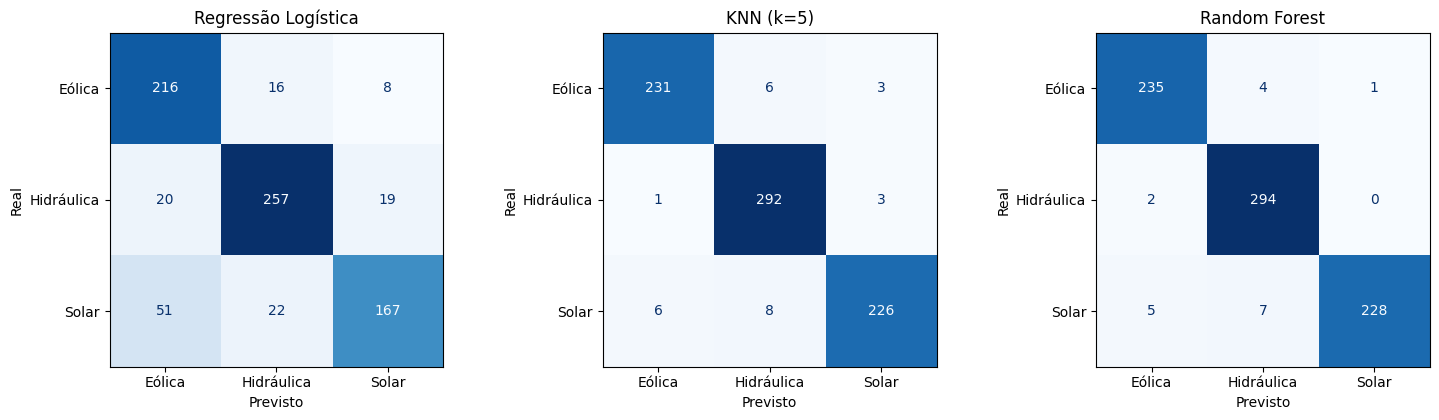

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for ax, (nome, cm) in zip(axes, matrizes.items()):
    ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(nome); ax.set_xlabel("Previsto"); ax.set_ylabel("Real")
plt.tight_layout(); plt.show()

In [9]:
for nome, p in previsoes.items():
    print("=" * 60); print(nome); print(classification_report(y_te, p, labels=classes, digits=3))

Regressão Logística
              precision    recall  f1-score   support

      Eólica      0.753     0.900     0.820       240
  Hidráulica      0.871     0.868     0.870       296
       Solar      0.861     0.696     0.770       240

    accuracy                          0.825       776
   macro avg      0.828     0.821     0.820       776
weighted avg      0.831     0.825     0.823       776

KNN (k=5)
              precision    recall  f1-score   support

      Eólica      0.971     0.963     0.967       240
  Hidráulica      0.954     0.986     0.970       296
       Solar      0.974     0.942     0.958       240

    accuracy                          0.965       776
   macro avg      0.966     0.964     0.965       776
weighted avg      0.965     0.965     0.965       776

Random Forest
              precision    recall  f1-score   support

      Eólica      0.971     0.979     0.975       240
  Hidráulica      0.964     0.993     0.978       296
       Solar      0.996     0.9

### 1.4 Interpretação — classificação

| Modelo | Accuracy | F1 (macro) |
|---|---|---|
| Regressão Logística | ≈ 0,825 | ≈ 0,820 |
| KNN (k=5) | ≈ 0,965 | ≈ 0,965 |
| Random Forest | ≈ 0,976 | ≈ 0,975 |

**Escolha:** o **Random Forest** foi o melhor em todas as métricas e é o que eu escolheria; o KNN fica muito perto. A Regressão Logística é bem pior porque tenta separar as três classes com fronteiras lineares, e a relação entre potência, coordenadas e fonte é claramente não linear (regiões geográficas e faixas de potência específicas).

**Classes mais confundidas:** na Regressão Logística, o maior erro é **Solar classificada como Eólica** (51 casos) — solares com potência baixa e coordenadas no Nordeste/Sul são vistas como eólicas. No KNN e no Random Forest a maior confusão passa a ser **Solar ↔ Hidráulica** (Solar prevista como Hidráulica em 7 a 8 casos), enquanto Eólica e Hidráulica quase não se confundem.

**Limitações de prever a fonte só por potência e localização:**
1. **Potência outorgada não é energia gerada**: é a potência nominal autorizada, e o cadastro mistura empreendimentos em fases diferentes (em projeto, em construção, operando).
2. **Coordenadas aproximadas** e algumas ausentes (valor 0).
3. **Valores atípicos de potência** (solares com ≤ 1 kW, usinas hidráulicas gigantes) que não descrevem uma característica real da fonte.
4. **Proximidade espacial infla a nota**: parques eólicos e complexos hidráulicos têm muitas unidades quase no mesmo ponto. O KNN e o Random Forest conseguem "decorar" essas regiões, e uma unidade do teste costuma ter irmãs no treino. A divisão é aleatória e estratificada, não geográfica, então a acurácia de ~97% provavelmente é otimista para empreendimentos em locais novos.
5. Não existe contexto físico (relevo, vento, radiação, bacia hidrográfica), que é o que realmente determina a fonte.

**Checagem de duplicatas:** há 28 linhas duplicadas. Elas poderiam aparecer no treino e no teste ao mesmo tempo, então abaixo refaço a avaliação sem elas.

In [10]:
sem_dup = aneel.drop_duplicates()
Xd, yd = sem_dup[["potencia_kw", "latitude", "longitude"]], sem_dup["fonte"]
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(Xd, yd, test_size=0.2, stratify=yd, random_state=SEED)
linhas = []
for nome, modelo in modelos_clf.items():
    modelo.fit(Xd_tr, yd_tr)
    p = modelo.predict(Xd_te)
    linhas.append({"Modelo": nome, "Accuracy": accuracy_score(yd_te, p), "F1 (macro)": f1_score(yd_te, p, average="macro")})
print("Sem duplicatas:", len(sem_dup), "linhas")
pd.DataFrame(linhas).set_index("Modelo")

Sem duplicatas: 3848 linhas


,Accuracy,F1 (macro)
Modelo,,
Regressão Logística,0.8247,0.8182
KNN (k=5),0.9675,0.9673
Random Forest,0.9766,0.9764


A remoção das duplicatas quase não muda os resultados, então elas não explicam o desempenho alto; a explicação mais provável é a proximidade espacial descrita acima.

# Tarefa 2 — Regressão da radiação solar (Open-Meteo)

**Pergunta:** dadas temperatura, umidade, nuvens, vento e a hora local em Petrolina (PE), qual é a radiação solar global horizontal média daquela hora?

`X` = `temperatura_c`, `umidade_pct`, `nuvens_pct`, `vento_kmh`, `hora`; `y` = `radiacao_w_m2`. A coluna `data_hora` serve só para ordenar e dividir no tempo, **não é entrada**, e nenhuma transformação de `radiacao_w_m2` entra em `X`.

### 2.1 Exploração dos dados

In [11]:
meteo = pd.read_csv("meteo_regressao_orange.csv", encoding="utf-8-sig")
meteo["data_hora"] = pd.to_datetime(meteo["data_hora"])
print("Linhas e colunas:", meteo.shape)
print("Período:", meteo.data_hora.min(), "a", meteo.data_hora.max())
print("Ordem cronológica:", meteo.data_hora.is_monotonic_increasing)
print("\nValores ausentes:\n", meteo.isna().sum())
meteo.describe()

Linhas e colunas: (1001, 7)
Período: 2025-04-01 07:00:00 a 2025-06-30 17:00:00
Ordem cronológica: True

Valores ausentes:
 data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001,"1,001.0000","1,001.0000","1,001.0000","1,001.0000","1,001.0000","1,001.0000"
mean,2025-05-16 12:00:00,28.8859,50.5445,55.1089,15.4654,12.0000,472.8541
min,2025-04-01 07:00:00,19.5000,21.0000,0.0000,2.3000,7.0000,13.0000
25%,2025-04-23 15:00:00,26.3000,38.0000,19.0000,12.2000,9.0000,250.0000
50%,2025-05-16 12:00:00,29.1000,49.0000,54.0000,15.4000,12.0000,466.0000
75%,2025-06-08 09:00:00,31.7000,61.0000,98.0000,19.0000,15.0000,696.0000
max,2025-06-30 17:00:00,36.1000,95.0000,100.0000,30.1000,17.0000,"1,002.0000"
std,NaN,3.6565,15.9140,37.8515,4.9236,3.1639,256.3690


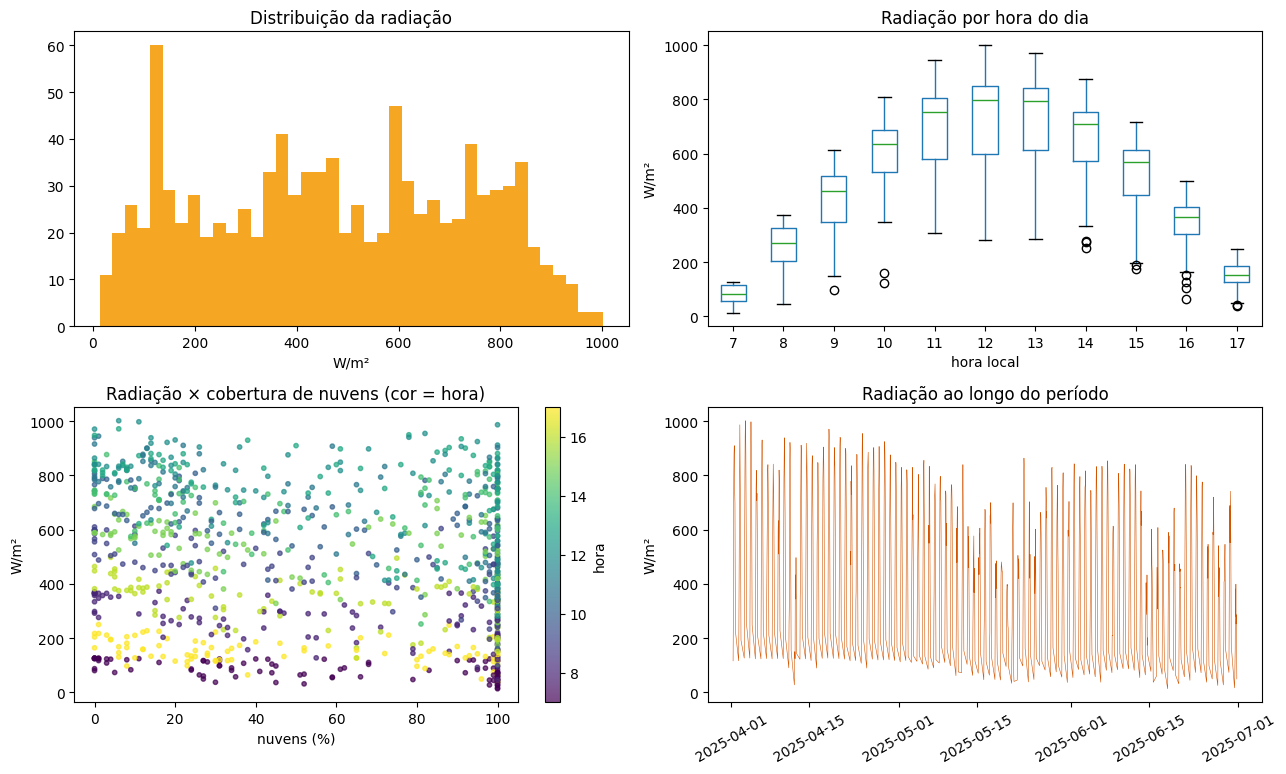

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes[0, 0].hist(meteo.radiacao_w_m2, bins=40, color="#f5a623"); axes[0, 0].set(title="Distribuição da radiação", xlabel="W/m²")
meteo.boxplot(column="radiacao_w_m2", by="hora", ax=axes[0, 1], grid=False)
axes[0, 1].set(title="Radiação por hora do dia", xlabel="hora local", ylabel="W/m²"); fig.suptitle("")
sc = axes[1, 0].scatter(meteo.nuvens_pct, meteo.radiacao_w_m2, c=meteo.hora, cmap="viridis", s=10, alpha=.7)
axes[1, 0].set(title="Radiação × cobertura de nuvens (cor = hora)", xlabel="nuvens (%)", ylabel="W/m²"); plt.colorbar(sc, ax=axes[1, 0], label="hora")
axes[1, 1].plot(meteo.data_hora, meteo.radiacao_w_m2, lw=.4, color="#d35400"); axes[1, 1].set(title="Radiação ao longo do período", ylabel="W/m²")
axes[1, 1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

In [13]:
meteo.drop(columns="data_hora").corr().round(2)

,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
temperatura_c,1.0000,-0.9300,-0.1700,-0.4000,0.7000,0.6400
umidade_pct,-0.9300,1.0000,0.1600,0.2200,-0.7300,-0.6000
nuvens_pct,-0.1700,0.1600,1.0000,0.2100,-0.0300,-0.1800
vento_kmh,-0.4000,0.2200,0.2100,1.0000,-0.0800,-0.2300
hora,0.7000,-0.7300,-0.0300,-0.0800,1.0000,0.1200
radiacao_w_m2,0.6400,-0.6000,-0.1800,-0.2300,0.1200,1.0000


**O que se vê:** a radiação tem um ciclo diário claro, com mínimo às 7h e 17h e pico perto do meio-dia (boxplot por hora). Por isso a **hora** é a variável mais importante: ela sozinha explica boa parte do nível de radiação. A relação com a hora é uma **curva em forma de sino**, não uma reta, e a correlação linear simples de `hora` com a radiação é baixa (≈ 0,12), mesmo a variável sendo decisiva. Isso já antecipa o fraco desempenho do modelo linear. Nuvens reduzem a radiação, mas com muita dispersão, e a temperatura sobe junto com a radiação ao longo do dia.

### 2.2 Divisão temporal
As **primeiras 80%** das horas vão para treino e as **últimas 20%** para teste, **sem embaralhar**. Os três modelos usam a mesma divisão.

In [14]:
features = ["temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora"]
alvo = "radiacao_w_m2"
meteo = meteo.sort_values("data_hora").reset_index(drop=True)
corte = int(len(meteo) * 0.8)
treino, teste = meteo.iloc[:corte], meteo.iloc[corte:]
X_tr2, y_tr2 = treino[features], treino[alvo]
X_te2, y_te2 = teste[features], teste[alvo]
print(f"Treino: {len(treino)} linhas ({treino.data_hora.min():%d/%m} a {treino.data_hora.max():%d/%m})")
print(f"Teste:  {len(teste)} linhas ({teste.data_hora.min():%d/%m} a {teste.data_hora.max():%d/%m})")
print(f"Radiação média — treino: {y_tr2.mean():.1f} W/m² | teste: {y_te2.mean():.1f} W/m²")

Treino: 800 linhas (01/04 a 12/06)
Teste:  201 linhas (12/06 a 30/06)
Radiação média — treino: 497.8 W/m² | teste: 373.4 W/m²


Note que o teste cobre só o fim do período (de 12/06 a 30/06) e tem radiação média menor que a do treino. Isso é esperado em uma divisão temporal: o modelo é avaliado em dias mais próximos do inverno, que não viu no treino.

### 2.3 Treino e comparação dos três regressores
- **Regressão Linear** (linha de base).
- **Árvore de Decisão** com `max_depth=6`.
- **Random Forest** com 200 árvores.

Nenhum usa padronização, porque os dois últimos não precisam dela e a Regressão Linear não é afetada pela escala (os coeficientes só mudam de unidade).

In [15]:
modelos_reg = {
    "Regressão Linear":  LinearRegression(),
    "Árvore de Decisão": DecisionTreeRegressor(max_depth=6, random_state=SEED),
    "Random Forest":     RandomForestRegressor(n_estimators=200, random_state=SEED),
}
linhas, pred_reg = [], {}
for nome, modelo in modelos_reg.items():
    modelo.fit(X_tr2, y_tr2)
    p = modelo.predict(X_te2)
    pred_reg[nome] = p
    linhas.append({"Modelo": nome,
                   "MAE (W/m²)": mean_absolute_error(y_te2, p),
                   "MSE ((W/m²)²)": mean_squared_error(y_te2, p),
                   "RMSE (W/m²)": np.sqrt(mean_squared_error(y_te2, p)),
                   "R²": r2_score(y_te2, p)})
resultados_reg = pd.DataFrame(linhas).set_index("Modelo")
resultados_reg

,MAE (W/m²),MSE ((W/m²)²),RMSE (W/m²),R²
Modelo,,,,
Regressão Linear,145.2049,"30,034.2011",173.3038,0.3598
Árvore de Decisão,90.9377,"15,127.0271",122.9920,0.6776
Random Forest,66.2517,"7,250.8882",85.1521,0.8455


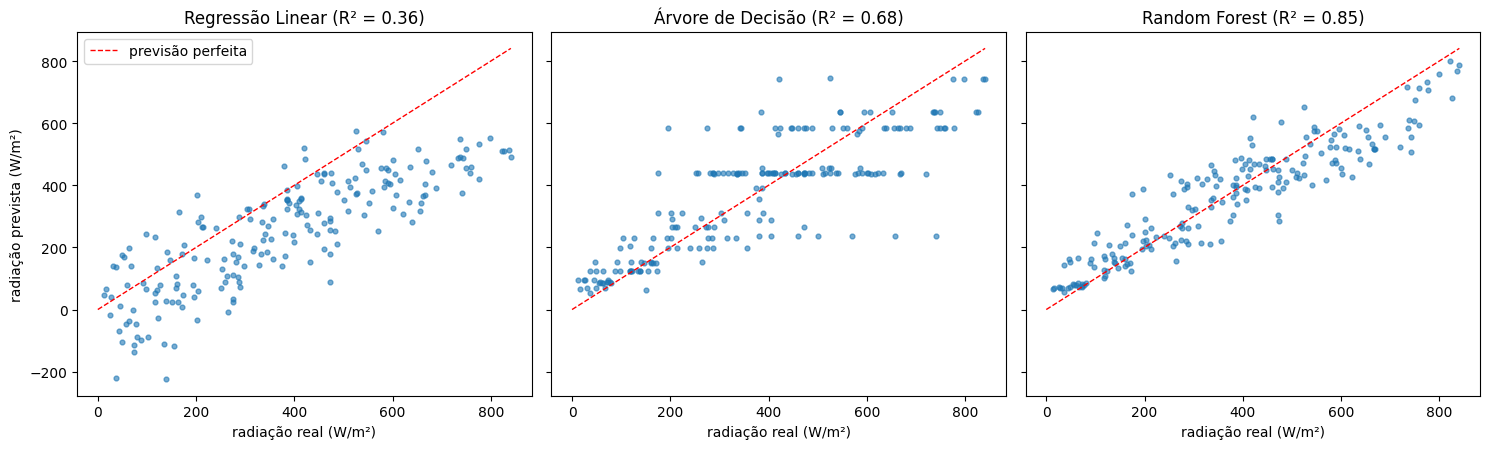

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharex=True, sharey=True)
lim = [0, max(y_te2.max(), max(p.max() for p in pred_reg.values()))]
for ax, (nome, p) in zip(axes, pred_reg.items()):
    ax.scatter(y_te2, p, s=12, alpha=.6)
    ax.plot(lim, lim, "r--", lw=1, label="previsão perfeita")
    ax.set(title=f"{nome} (R² = {r2_score(y_te2, p):.2f})", xlabel="radiação real (W/m²)")
axes[0].set_ylabel("radiação prevista (W/m²)"); axes[0].legend()
plt.tight_layout(); plt.show()

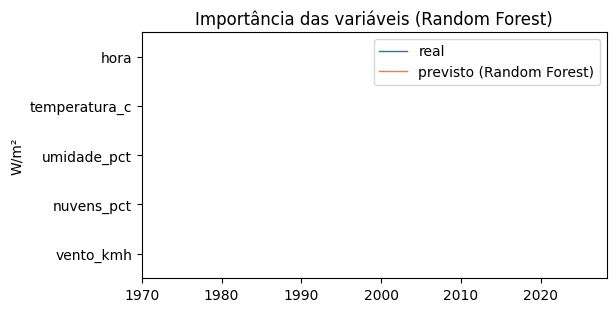

In [17]:
melhor = "Random Forest"
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(teste.data_hora.values, y_te2.values, label="real", lw=1)
ax.plot(teste.data_hora.values, pred_reg[melhor], label=f"previsto ({melhor})", lw=1)
ax.set(title="Período de teste: real × previsto", ylabel="W/m²"); ax.legend(); plt.show()

importancias = pd.Series(modelos_reg[melhor].feature_importances_, index=features).sort_values()
importancias.plot.barh(title="Importância das variáveis (Random Forest)", figsize=(6, 3.2)); plt.show()

### 2.4 Interpretação — regressão

| Modelo | MAE (W/m²) | MSE ((W/m²)²) | R² |
|---|---|---|---|
| Regressão Linear | ≈ 145 | ≈ 30 034 | ≈ 0,36 |
| Árvore de Decisão | ≈ 91 | ≈ 15 127 | ≈ 0,68 |
| Random Forest | ≈ 66 | ≈ 7 251 | ≈ 0,85 |

**Resultado:** o **Random Forest** é o melhor, com erro médio de cerca de 66 W/m² (a radiação média é ~470 W/m²). A Árvore de Decisão vem em seguida e a Regressão Linear é a pior, com erro mais que o dobro. O motivo está no gráfico de exploração: o ciclo solar é uma curva em sino, e uma reta em função da hora não consegue representá-la. Modelos baseados em árvores criam faixas de hora e combinações (hora + nuvens) e acompanham melhor esse padrão. No gráfico real × previsto, a Regressão Linear espalha os pontos longe da diagonal, inclusive prevendo radiação negativa em 19 das 201 horas de teste (mínimo ≈ −224 W/m², fisicamente impossível), enquanto o Random Forest se concentra em torno dela.

**Papel da hora do dia:** é a variável mais importante do Random Forest (cerca de metade da importância). A hora define o ângulo do sol e, portanto, o teto de radiação possível; nuvens, umidade e temperatura só modulam esse valor. Sem `hora`, o modelo perderia o principal sinal. A temperatura e a umidade também aparecem com peso alto, em parte porque variam junto com a hora do dia (são proxies do ciclo diário).

**Limitações:**
- Os dados são estimativas de **modelos/reanálise do Open-Meteo**, não medições de sensor.
- Cobrem **um local e três meses**; o modelo não se generaliza para outras cidades ou estações.
- O teste é um período só (fim de junho), então os números dependem dessa janela.

**Radiação não é geração elétrica.** Radiação em W/m² mede a energia solar que chega por área; a geração de uma usina depende também da área e da eficiência dos painéis, da temperatura de operação, da orientação e inclinação, de sombreamento e sujeira, de perdas no inversor e na rede, e de eventuais cortes de operação. Portanto estimar a radiação é um passo útil, mas **não prevê automaticamente quanta energia um sistema fotovoltaico vai produzir**.

# Conclusão geral
Nas duas tarefas o **Random Forest** foi o melhor modelo, e o modelo linear foi o pior, porque as relações são não lineares. Em ambos os casos, os resultados precisam ser lidos com cuidado: na classificação, a acurácia alta é favorecida pela proximidade espacial dos empreendimentos e por valores peculiares do cadastro; na regressão, o resultado vale para um local, um período e dados estimados por modelo.